#### Arithmetic Operations on Images

In [15]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [4]:
img1 = cv2.imread('132.png')
img2 = cv2.imread('opencv_logo.png')
dst = cv2.addWeighted(img1,0.7,img2,0.3,0)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

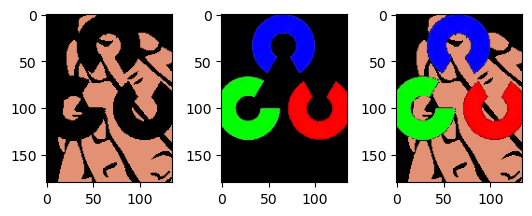

In [47]:
# Load two images
img1 = cv2.imread('132.png')
img2 = cv2.imread('OIP.jpg')
# I want to put logo on top-left corner, So I create a ROI
rows,cols,channels = img2.shape
roi = img1[0:rows, 0:cols ]
# Now create a mask of logo and create its inverse mask also
img2gray = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

ret, mask = cv2.threshold(img2gray, 20, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)
# Now black-out the area of logo in ROI
img1_bg = cv2.bitwise_and(roi,roi,mask = mask_inv)
# Take only region of logo from logo image.
img2_fg = cv2.bitwise_and(img2,img2,mask = mask)
dst = cv2.add(img1_bg,img2_fg)
img1[0:rows, 0:cols ] = dst

plt.subplot(231),plt.imshow(img1_bg)
plt.subplot(232),plt.imshow(img2_fg, 'gray')
plt.subplot(233),plt.imshow(dst)
plt.show()




In [48]:
cv2.imshow('res',img1)
cv2.waitKey(0)
cv2.destroyAllWindows()
